# Data Preprocessing

In this tutorial you will learn to:
- Detect and handle **outliers** using clipping
- Impute **missing values** with sklearn
- Apply **feature scaling** (StandardScaler, MinMaxScaler, RobustScaler)
- Apply a **log transformation** to a skewed target

We'll work with a **used car sales** dataset — over 3,500 listings with age, mileage, and selling price. The target ranges from 20,000 to nearly 9,000,000 INR, a span wide enough to illustrate every preprocessing challenge covered here.

Before a model can learn from data, the data usually needs to be cleaned and transformed. Missing values cause sklearn to raise an error and refuse to train. Features on wildly different scales mislead gradient-based and distance-based algorithms. A heavily skewed target means a handful of extreme values dominate the loss function during training. Preprocessing fixes these problems before learning starts.

The single rule that ties every step together: **split your data before fitting any transformation.** Scalers, imputers, and encoders all learn statistics from data — means, medians, standard deviations. If you compute those statistics on the full dataset before splitting, test data contaminates your training statistics, your evaluation becomes too optimistic, and the model will fail on genuinely unseen data.

> **The correct order, always: split first → fit transformations on training data only → apply the same fitted objects to both train and test.**

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')

RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)

---
## Step 2: Load and Inspect the Data

> **Data source:** *Car Details from CarDekho* — used-car listings (specifications and asking prices) from CarDekho.com, compiled and published on Kaggle (e.g., the *Car Details Dataset* by Akshay Dattatray Khare).

In [2]:
df = pd.read_csv('car_price.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (4340, 9)


,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner
0,Maruti,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
# A car's age predicts price more directly than its manufacturing year, so we'll convert Year -> car_age.
# Turning a year into an age needs a reference year — and the data tells us what's reasonable,
# so first look at the range of model years:
print(f"Model years in the data: {df['Year'].min()} to {df['Year'].max()}")

# The newest models are 2020, so these listings date to about 2020-2021. We anchor age to one
# year past the newest model (so the newest cars are age 1, not 0). Deriving the reference from
# the data — rather than today's date — keeps every number in this tutorial reproducible.
REFERENCE_YEAR = df['Year'].max() + 1
df['car_age'] = REFERENCE_YEAR - df['Year']
print(f"Reference year: {REFERENCE_YEAR}\n")

# EDA overview: every column's data type and how many values are present (non-null)
df.info()

Model years in the data: 1992 to 2020
Reference year: 2021

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Brand          4340 non-null   str  
 1   Model          4340 non-null   str  
 2   Year           4340 non-null   int64
 3   Selling_Price  4340 non-null   int64
 4   KM_Driven      4340 non-null   int64
 5   Fuel           4340 non-null   str  
 6   Seller_Type    4340 non-null   str  
 7   Transmission   4340 non-null   str  
 8   Owner          4340 non-null   str  
 9   car_age        4340 non-null   int64
dtypes: int64(4), str(6)
memory usage: 339.3 KB


### What we'll use, and what we set aside

The dataset has nine original columns, but this tutorial is about preprocessing **numerical** data. We'll predict `Selling_Price` from two numerical features: `KM_Driven`, and `car_age` (derived above from `Year`).

The categorical columns — `Brand`, `Model`, `Fuel`, `Seller_Type`, `Transmission`, `Owner` — carry real signal too, but a model can't do arithmetic on text: they have to be turned into numbers first through categorical encoding, a separate topic. We set them aside here.

`df.info()` above shows every column is complete — there are no missing values yet, so we'll introduce some ourselves later to practice imputation.

### Remove duplicate rows

The raw file contains exact duplicate rows (a common data-collection artifact). We drop them so no listing is counted more than once during training.

In [4]:
# Drop exact duplicate rows (rows identical across every column)
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)

print(f'Shape after dropping duplicates: {df.shape}')
df[['car_age', 'KM_Driven', 'Selling_Price']].head()

Duplicate rows: 763
Shape after dropping duplicates: (3577, 10)


,car_age,KM_Driven,Selling_Price
0,14,70000,60000
1,14,50000,135000
2,9,100000,600000
3,4,46000,250000
4,7,141000,450000


In [5]:
numerical_features = ['car_age', 'KM_Driven']
target = 'Selling_Price'

df[numerical_features + [target]].describe().round(0)

,car_age,KM_Driven,Selling_Price
count,3577.0,3577.0,3577.0
mean,8.0,69251.0,473913.0
std,4.0,47580.0,509302.0
min,1.0,1.0,20000.0
25%,5.0,36000.0,200000.0
50%,8.0,60000.0,350000.0
75%,11.0,90000.0,600000.0
max,29.0,806599.0,8900000.0


In [6]:
print('Feature value ranges:')
for feat in numerical_features:
    print(f'  {feat:12s}: {df[feat].min():.0f} to {df[feat].max():,.0f}')
print(f'\ncar_age spans ~{int(df["car_age"].max() - df["car_age"].min())} units, '
      f'KM_Driven spans ~{int(df["KM_Driven"].max() - df["KM_Driven"].min()):,} units.')
print('This scale mismatch matters — we will address it in Step 6.')

Feature value ranges:
  car_age     : 1 to 29
  KM_Driven   : 1 to 806,599

car_age spans ~28 units, KM_Driven spans ~806,598 units.
This scale mismatch matters — we will address it in Step 6.


---
## Step 3: Split the Data

We've loaded, cleaned, and inspected the data. Before we transform anything, we split it — and this is the single most important habit in preprocessing.

Every transformation ahead — an outlier threshold, an imputation median, a scaler's mean and standard deviation — is a statistic *learned from data*. Computing it from the full dataset lets information from the test set leak into training: your evaluation looks better than it really is, and the model underperforms on genuinely unseen data.

So from here on: **split first, fit each transformation on the training set only, then apply it to both train and test.** The test set is only ever transformed — never measured from.

In [7]:
# Split the data. Everything we fit from here on (thresholds, medians, scalers) uses X_train only.
X = df[numerical_features].values.astype(float)   # float so we can introduce NaN later
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)
KM = numerical_features.index('KM_Driven')   # column index reused below
print(KM)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

1
Train: (2861, 2)  |  Test: (716, 2)


---
## Step 4: Outlier Treatment

Outliers are values far outside the typical range. For a linear regression, extreme points pull the fitted coefficients toward them — reducing accuracy for the majority of the data to slightly reduce error on the extremes.

`KM_Driven` has genuine extreme values: a handful of cars have over 500,000 km on the odometer. Three options:
- **Remove**: delete the row entirely. Only appropriate for clear data errors (negative mileage, physically impossible values).
- **Clip**: cap the value at a threshold (e.g., the 99th percentile). The row stays in the dataset; only the extreme value is replaced with the boundary value.
- **Keep**: if the outlier is a real, meaningful observation, removing it discards information.

We'll clip `KM_Driven` — the extreme readings are valid, but rare enough that leaving them uncapped would pull the fitted line away from the typical range. Following the rule we just set, we compute the threshold from the **training set only**, then apply it to both splits.

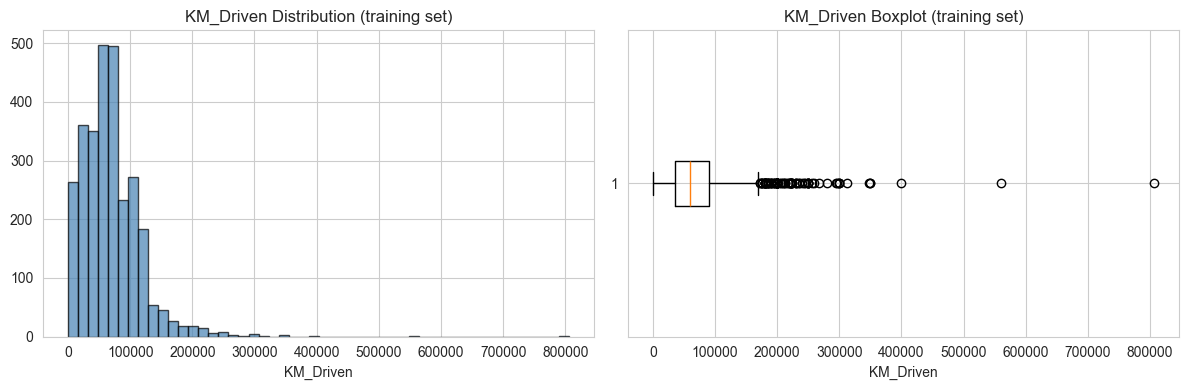

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train[:, KM], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('KM_Driven')
axes[0].set_title('KM_Driven Distribution (training set)')

axes[1].boxplot(X_train[:, KM], vert=False)
axes[1].set_xlabel('KM_Driven')
axes[1].set_title('KM_Driven Boxplot (training set)')

plt.tight_layout()
plt.show()

In [9]:
# Explore the outliers on the TRAINING set (the only data we're allowed to learn from)
km_train = X_train[:, KM]
Q1 = np.percentile(km_train, 25)
Q3 = np.percentile(km_train, 75)
IQR = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR
p99 = np.percentile(km_train, 99)

iqr_pct = (km_train > upper_iqr).mean() * 100
p99_pct = (km_train > p99).mean() * 100

print(f'IQR upper bound:  {upper_iqr:,.0f} km  ->  {(km_train > upper_iqr).sum()} rows ({iqr_pct:.1f}%)')
print(f'99th percentile:  {p99:,.0f} km  ->  {(km_train > p99).sum()} rows ({p99_pct:.1f}%)')
print(f'Maximum value:    {km_train.max():,.0f} km')
print()
print('Decision: clip at the 99th percentile.')
print(f'The IQR rule flags {iqr_pct:.1f}% of rows — may include legitimate high-mileage cars.')
print(f'The 99th percentile limits impact to only the {p99_pct:.1f}% most extreme values.')

IQR upper bound:  171,000 km  ->  86 rows (3.0%)
99th percentile:  226,785 km  ->  29 rows (1.0%)
Maximum value:    806,599 km

Decision: clip at the 99th percentile.
The IQR rule flags 3.0% of rows — may include legitimate high-mileage cars.
The 99th percentile limits impact to only the 1.0% most extreme values.


Training 99th-percentile threshold: 226,785 km
Train KM_Driven max — before: 806,599  ->  after: 226,785
Training rows clipped: 29


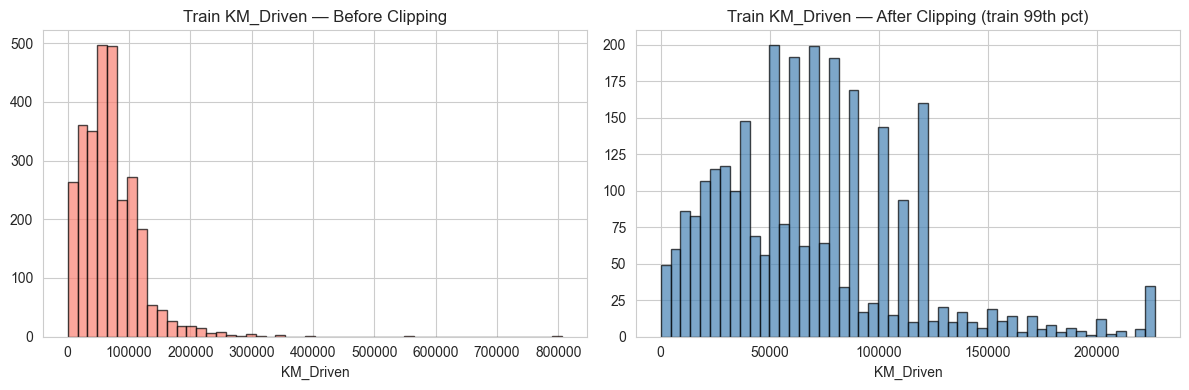

In [10]:
# Clip KM_Driven using a threshold computed from the TRAINING set only,
# then apply that same threshold to both train and test.
KM = numerical_features.index('KM_Driven')   # column index of KM_Driven

p99_train = np.percentile(X_train[:, KM], 99)
km_train_before = X_train[:, KM].copy()

X_train[:, KM] = np.clip(X_train[:, KM], a_min=None, a_max=p99_train)
X_test[:, KM]  = np.clip(X_test[:, KM],  a_min=None, a_max=p99_train)

print(f'Training 99th-percentile threshold: {p99_train:,.0f} km')
print(f'Train KM_Driven max — before: {km_train_before.max():,.0f}  ->  after: {X_train[:, KM].max():,.0f}')
print(f'Training rows clipped: {(km_train_before > p99_train).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(km_train_before, bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[0].set_title('Train KM_Driven — Before Clipping')
axes[0].set_xlabel('KM_Driven')
axes[1].hist(X_train[:, KM], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title('Train KM_Driven — After Clipping (train 99th pct)')
axes[1].set_xlabel('KM_Driven')
plt.tight_layout()
plt.show()

---
## Step 5: Handling Missing Data

The dataset has no missing values in its numerical features, but real data rarely arrives this clean. We'll introduce some into both the training and test sets to practice the correct imputation workflow — this mirrors what you'll encounter in production.

`sklearn` models raise a `ValueError` when they receive `NaN` values. `SimpleImputer` fills missing values using a statistic you choose: median, mean, most frequent, or a constant. The critical constraint: **fit the imputer on training data only**, then apply the same fixed values to both train and test.

In [11]:
# Introduce ~5% missing values in car_age, in BOTH splits (real data has gaps everywhere).
# car_age is column 0; the arrays are already float, so they can hold NaN.
CAR_AGE = numerical_features.index('car_age')
rng = np.random.default_rng(RANDOM_SEED + 1)

train_nan = rng.choice(len(X_train), size=int(0.05 * len(X_train)), replace=False)
test_nan  = rng.choice(len(X_test),  size=int(0.05 * len(X_test)),  replace=False)
X_train[train_nan, CAR_AGE] = np.nan
X_test[test_nan,  CAR_AGE] = np.nan

print(f'Missing car_age — train: {np.isnan(X_train[:, CAR_AGE]).sum()} rows, '
      f'test: {np.isnan(X_test[:, CAR_AGE]).sum()} rows')

Missing car_age — train: 143 rows, test: 35 rows


In [12]:
# Attempt to train without imputation
try:
    LinearRegression().fit(X_train, y_train)
except ValueError as e:
    print(f'ValueError: {e}')
    print('\nThe model refuses to train on data containing NaN values.')
    print('Imputation is required before training.')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

The model refuses to train on data containing NaN values.
Imputation is required before training.


In [13]:
# Correct approach: fit imputer on training data only, apply to both sets
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)  # learns medians from training data only

X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)

print('Medians learned from training data:')
for name, val in zip(numerical_features, imputer.statistics_):
    print(f'  {name}: {val:.1f}')

rows_with_nan = np.isnan(X_train).any(axis=1).sum()
print(f'\nRows affected by NaN in training set: {rows_with_nan}')
print(f'After imputation: 0 NaN values, all {len(X_train_imp)} training rows usable')

Medians learned from training data:
  car_age: 7.0
  KM_Driven: 60400.0

Rows affected by NaN in training set: 143
After imputation: 0 NaN values, all 2861 training rows usable


### The fit / transform pattern

Notice the two-step shape of what we just did:

- `imputer.fit(X_train)` — **learn** the statistic (here, the median) from training data
- `imputer.transform(X_train)` and `imputer.transform(X_test)` — **apply** it to each set

Every sklearn preprocessing object — imputers, scalers, encoders — follows this same **fit / transform** contract. It is the transformer counterpart to the **fit / predict** pattern you used for models: both *learn* with `.fit()`; a model then `.predict()`s, while a transformer `.transform()`s.

`fit_transform(X_train)` is simply `fit` then `transform` in one call — a convenience for the training set (you'll see it used for the scaler next). The golden rule, restated in API terms: **`fit` on training data only; `transform` both.**

### Imputer strategy reference

| Strategy | When to use |
|---|---|
| `strategy='median'` | Numerical feature with skew or outliers — robust default |
| `strategy='mean'` | Numerical feature that is roughly symmetric and outlier-free |
| `strategy='most_frequent'` | Categorical or binary features |
| `strategy='constant'` | When a specific fill value is meaningful (e.g., `fill_value=0`) |

---
## Step 6: Feature Scaling

Our two features are on very different scales:
- `car_age`: 1–29 (a ~28-unit range)
- `KM_Driven`: 1–~227,000 after clipping (a ~227,000-unit range)

For gradient-based training, this is a problem. The gradient update for each parameter is proportional to the feature's magnitude. With a single learning rate, the optimizer must simultaneously handle gradients that differ by more than three orders of magnitude — it cannot efficiently update `car_age` and `KM_Driven` at the same time.

For distance-based algorithms (KNN, SVM, clustering), the effect is more direct: `KM_Driven` will dominate every distance calculation regardless of how informative it actually is.

Scaling brings features to a comparable range without changing the information they carry.

### Three main scalers

| Scaler | What it does | When to use |
|---|---|---|
| **StandardScaler** | Centers at 0, scales to std=1 | Good default for most models |
| **MinMaxScaler** | Maps to [0, 1] | When a bounded range is required; sensitive to outliers |
| **RobustScaler** | Uses median + IQR (outlier-resistant) | Best when outliers are severe and can't be removed |

In [14]:
# Fit on imputed (but not yet scaled) training data
model = LinearRegression()
model.fit(X_train_imp, y_train)

print('Coefficients WITHOUT scaling (units: INR per one unit of feature):')
for name, coef in zip(numerical_features, model.coef_):
    print(f'  {name:12s}: {coef:>15,.1f}')
print()
print('The coefficient values reflect the feature units, not their importance.')
print('A 1-year increase in car_age has a large-magnitude effect in rupees.')
print('A 1-km increase in KM_Driven has a tiny effect.')
print('You cannot compare these two numbers to decide which feature matters more.')

Coefficients WITHOUT scaling (units: INR per one unit of feature):
  car_age     :       -50,924.9
  KM_Driven   :            -0.1

The coefficient values reflect the feature units, not their importance.
A 1-year increase in car_age has a large-magnitude effect in rupees.
A 1-km increase in KM_Driven has a tiny effect.
You cannot compare these two numbers to decide which feature matters more.


In [15]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# StandardScaler: fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

model.fit(X_train_scaled, y_train)
print('Coefficients WITH StandardScaler (units: INR per standard deviation):')
for name, coef in zip(numerical_features, model.coef_):
    print(f'  {name:12s}: {coef:>15,.1f}')
print()
print('Now both are in comparable units. Larger absolute value = stronger influence.')
print()

# For OLS linear regression, scaling changes coefficient magnitudes but not predictions
rmse_unscaled = rmse(y_test, LinearRegression().fit(X_train_imp, y_train).predict(X_test_imp))
rmse_scaled   = rmse(y_test, LinearRegression().fit(X_train_scaled, y_train).predict(X_test_scaled))
print(f'RMSE without scaling: {rmse_unscaled:,.0f} INR')
print(f'RMSE with scaling:    {rmse_scaled:,.0f} INR')
print()
print('Identical. OLS solves for its coefficients with a direct formula, so feature scale')
print('cannot change its predictions — only the coefficient magnitudes. OLS is the exception.')
print('The next cell shows what happens to a model that learns by gradient descent.')

Coefficients WITH StandardScaler (units: INR per standard deviation):
  car_age     :      -209,601.8
  KM_Driven   :        -2,741.0

Now both are in comparable units. Larger absolute value = stronger influence.

RMSE without scaling: 479,591 INR
RMSE with scaling:    479,591 INR

Identical. OLS solves for its coefficients with a direct formula, so feature scale
cannot change its predictions — only the coefficient magnitudes. OLS is the exception.
The next cell shows what happens to a model that learns by gradient descent.


### Why scaling matters: watch a gradient-based model

OLS is the exception, not the rule: it solves for its coefficients with a direct formula, so feature scale can't affect its predictions. Most models — including the gradient-descent linear regression you built earlier, and every neural network — learn their weights by taking many small steps, and those steps go haywire when one feature's range dwarfs another's.

`SGDRegressor` is linear regression trained by gradient descent. Here is the *same* model on the same data, once with unscaled features and once with scaled ones.

In [16]:
import warnings

# Same gradient-based model; the only difference is whether the features are scaled.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # silence convergence/overflow noise — the RMSE tells the story

    sgd_unscaled = SGDRegressor(max_iter=1000, random_state=RANDOM_SEED)
    sgd_unscaled.fit(X_train_imp, y_train)
    rmse_sgd_unscaled = rmse(y_test, sgd_unscaled.predict(X_test_imp))

    sgd_scaled = SGDRegressor(max_iter=1000, random_state=RANDOM_SEED)
    sgd_scaled.fit(X_train_scaled, y_train)
    rmse_sgd_scaled = rmse(y_test, sgd_scaled.predict(X_test_scaled))

print(f'Gradient descent on UNSCALED features: RMSE = {rmse_sgd_unscaled:.2e} INR   <- diverged')
print(f'Gradient descent on SCALED features:   RMSE = {rmse_sgd_scaled:,.0f} INR')
print()
print('Unscaled, the huge KM_Driven gradients blow the optimizer up and the error explodes to a')
print('meaningless magnitude. Scaled, the same model converges to roughly the OLS error above.')
print('This is the lesson: scaling is essential the moment a model learns by gradient descent')
print('(or measures distances) — even though plain OLS happens to be immune to it.')

Gradient descent on UNSCALED features: RMSE = 1.85e+18 INR   <- diverged
Gradient descent on SCALED features:   RMSE = 479,415 INR

Unscaled, the huge KM_Driven gradients blow the optimizer up and the error explodes to a
meaningless magnitude. Scaled, the same model converges to roughly the OLS error above.
This is the lesson: scaling is essential the moment a model learns by gradient descent
(or measures distances) — even though plain OLS happens to be immune to it.


In [17]:
# RobustScaler: uses median and IQR instead of mean and std
rob_scaler = RobustScaler()
X_train_rob = rob_scaler.fit_transform(X_train_imp)

print('RobustScaler parameters learned from training data:')
for i, name in enumerate(numerical_features):
    print(f'  {name:12s}: center={rob_scaler.center_[i]:.1f} (median), scale={rob_scaler.scale_[i]:.1f} (IQR)')
print()
print('RobustScaler is the right choice when outliers are present and influential —')
print('mean and std are distorted by extreme values; median and IQR are not.')

RobustScaler parameters learned from training data:
  car_age     : center=7.0 (median), scale=5.0 (IQR)
  KM_Driven   : center=60400.0 (median), scale=54000.0 (IQR)

RobustScaler is the right choice when outliers are present and influential —
mean and std are distorted by extreme values; median and IQR are not.


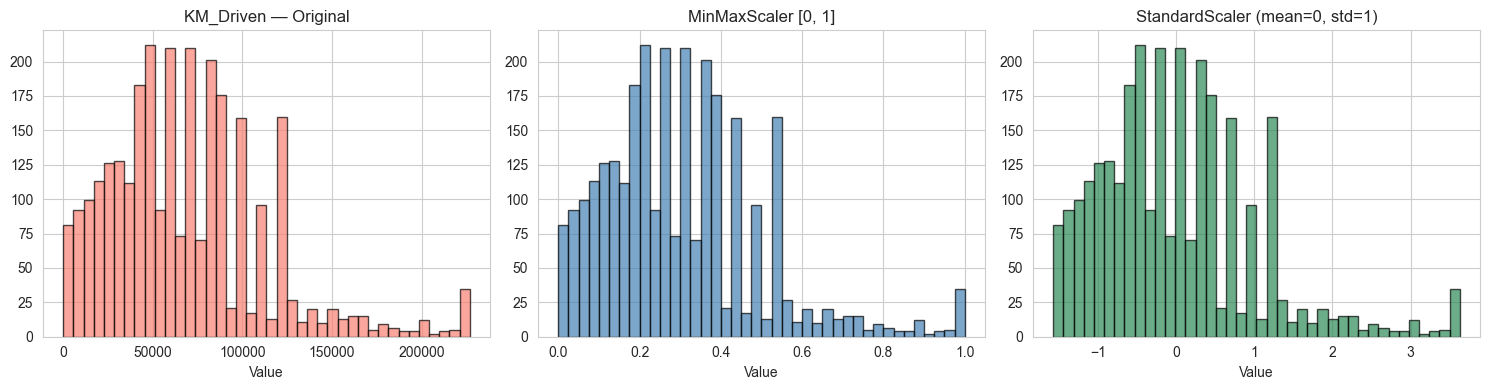

The shape of the distribution is unchanged — only the scale on the x-axis differs.


In [18]:
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train_imp)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data   = [X_train_imp[:, 1], X_train_mm[:, 1], X_train_scaled[:, 1]]
titles = ['KM_Driven — Original', 'MinMaxScaler [0, 1]', 'StandardScaler (mean=0, std=1)']
colors = ['salmon', 'steelblue', 'seagreen']

for ax, d, title, c in zip(axes, data, titles, colors):
    ax.hist(d, bins=40, edgecolor='black', alpha=0.7, color=c)
    ax.set_title(title)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()
print('The shape of the distribution is unchanged — only the scale on the x-axis differs.')

---
## Step 7: Log Transform on the Target

`Selling_Price` is heavily right-skewed: most cars sell for under 500,000 INR, but a small number sell for several million. When a linear regression trains on raw prices, the loss function is dominated by the expensive cars — minimizing a 5,000,000 INR error takes priority over dozens of 100,000 INR errors, even though the 100,000 INR cars are far more common.

Applying `np.log1p(price)` compresses the target into a roughly symmetric space, so every price range contributes more evenly to training. After predicting in log space, reverse with `np.expm1(prediction)` to get rupee values back. The `1p` suffix handles zero values: `log1p(x) = log(1 + x)`.

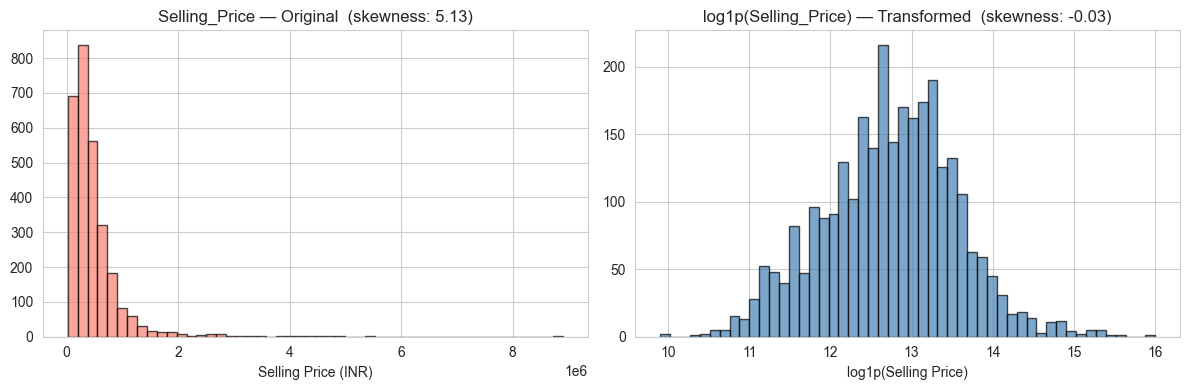

Skewness near 0 means the distribution is roughly symmetric.
The model will now fit across all price levels more evenly during training.


In [19]:
y_train_log = np.log1p(y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[0].set_title(f'Selling_Price — Original  (skewness: {pd.Series(y_train).skew():.2f})')
axes[0].set_xlabel('Selling Price (INR)')

axes[1].hist(y_train_log, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title(f'log1p(Selling_Price) — Transformed  (skewness: {pd.Series(y_train_log).skew():.2f})')
axes[1].set_xlabel('log1p(Selling Price)')

plt.tight_layout()
plt.show()

print('Skewness near 0 means the distribution is roughly symmetric.')
print('The model will now fit across all price levels more evenly during training.')

---
## Step 8: Full Preprocessing Pipeline

The correct order is always the same — every step that learns from data must use training data only:

1. **Split** the data
2. **Clip** outliers — threshold computed from training data, applied to both sets
3. **Impute** — fitted on training data, applied to both sets
4. **Scale** — fitted on training data, applied to both sets
5. **Log-transform** the target — applied to the training target; reversed on predictions
6. Train and evaluate

We run a baseline first (no clipping, drop NaN rows, raw target), then the full pipeline. We report **two** metrics so the effect of the log transform is visible:

- **RMSE** — average error in rupees. Because it measures absolute differences, it is dominated by the most expensive cars, where the rupee errors are largest.
- **RMSLE** — root mean squared *log* error. It penalizes *proportional* errors equally, so a 10% miss on a ₹200,000 car counts the same as a 10% miss on a ₹2,000,000 car. This is also the metric the House Prices competition uses.

In [20]:
# Self-contained run of the whole pipeline: rebuild the raw features, re-introduce ~5%
# missing car_age, then split. (This repeats the setup independently of the steps above.)
X_all = df[numerical_features].values.astype(float)
y_all = df[target].values.copy()

np.random.seed(RANDOM_SEED + 1)
nan_positions = np.random.choice(len(X_all), size=int(0.05 * len(X_all)), replace=False)
X_all[nan_positions, 0] = np.nan

# 1. Split — same split used for both models below
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=RANDOM_SEED)

# Evaluate both models on the same complete test rows — fair comparison
complete_te = ~np.isnan(X_te).any(axis=1)

def rmsle_score(y_true, y_pred):
    # RMSLE is undefined for negative predictions; clip the few a raw model can produce
    y_pred_clipped = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

# Baseline: drop NaN rows in training, no clipping, raw target
complete_tr = ~np.isnan(X_tr).any(axis=1)
b_model = LinearRegression()
b_model.fit(X_tr[complete_tr], y_tr[complete_tr])
pred_b = b_model.predict(X_te[complete_te])
rmse_b = rmse(y_te[complete_te], pred_b)
rmsle_b = rmsle_score(y_te[complete_te], pred_b)

print(f'Baseline (drop NaN, no clip, raw target):')
print(f'  RMSE  = {rmse_b:,.0f} INR')
print(f'  RMSLE = {rmsle_b:.3f}')
print(f'  Trained on {complete_tr.sum()} rows  ({(~complete_tr).sum()} dropped due to NaN)  |  negative predictions: {(pred_b < 0).sum()}')

Baseline (drop NaN, no clip, raw target):
  RMSE  = 455,278 INR
  RMSLE = 2.106
  Trained on 2716 rows  (145 dropped due to NaN)  |  negative predictions: 21


In [21]:
# Full pipeline: clip -> impute -> scale -> log-transform target
X_tr_p, X_te_p = X_tr.copy(), X_te.copy()

# 2. Clip — threshold from training data only
p99_tr = np.nanpercentile(X_tr_p[:, 1], 99)
X_tr_p[:, 1] = np.clip(X_tr_p[:, 1], None, p99_tr)
X_te_p[:, 1] = np.clip(X_te_p[:, 1], None, p99_tr)

# 3. Impute — fitted on training data only
imp = SimpleImputer(strategy='median')
X_tr_p = imp.fit_transform(X_tr_p)
X_te_p = imp.transform(X_te_p)

# 4. Scale — fitted on training data only
sc = StandardScaler()
X_tr_p = sc.fit_transform(X_tr_p)
X_te_p = sc.transform(X_te_p)

# 5. Log-transform target, train, reverse-transform predictions
p_model = LinearRegression()
p_model.fit(X_tr_p, np.log1p(y_tr))
y_pred_p = np.expm1(p_model.predict(X_te_p[complete_te]))
rmse_p = rmse(y_te[complete_te], y_pred_p)
rmsle_p = rmsle_score(y_te[complete_te], y_pred_p)

print(f'Full pipeline (clip + impute + scale + log target):')
print(f'  RMSE  = {rmse_p:,.0f} INR')
print(f'  RMSLE = {rmsle_p:.3f}')
print(f'  Trained on {len(X_tr_p)} rows  (+{len(X_tr_p) - complete_tr.sum()} retained by imputation)  |  negative predictions: {(y_pred_p < 0).sum()}')
print()
print(f'RMSE:  {rmse_b:,.0f} -> {rmse_p:,.0f} INR  (raw-rupee error can rise — the log model is not optimizing rupees)')
print(f'RMSLE: {rmsle_b:.3f} -> {rmsle_p:.3f}  ({(rmsle_b - rmsle_p)/rmsle_b*100:.0f}% improvement — the metric the House Prices competition uses)')

Full pipeline (clip + impute + scale + log target):
  RMSE  = 456,788 INR
  RMSLE = 0.563
  Trained on 2861 rows  (+145 retained by imputation)  |  negative predictions: 0

RMSE:  455,278 -> 456,788 INR  (raw-rupee error can rise — the log model is not optimizing rupees)
RMSLE: 2.106 -> 0.563  (73% improvement — the metric the House Prices competition uses)


### What each step contributes

**Clipping** caps the extreme `KM_Driven` readings (up to 806,599 km) that would otherwise pull the fitted line away from typical cars. **Imputation** retains the rows with missing `car_age` instead of discarding them, giving the model more training data. **Scaling** is kept here to preserve the standard pipeline order; it doesn't change OLS predictions (you saw that in the scaling step), but it becomes essential the moment you swap in a gradient-based or regularized model.

**Log transform on the target** changes what the model optimizes for. Trained on `log(price)`, the model minimizes *proportional* errors — a 10% miss on a ₹200,000 car is penalized like a 10% miss on a ₹2,000,000 car. RMSE, by contrast, measures absolute rupee differences, so the raw-target model pours its effort into the expensive end (where rupee errors are largest) at the expense of typical cars. That is why the log pipeline can show a *higher* rupee RMSE while scoring far better on **RMSLE**.

The large RMSLE drop reflects the log transform fixing **two problems at once**: it makes the model optimize proportional error (what RMSLE rewards), and — because `expm1()` output is always positive — it eliminates the negative price predictions a raw linear regression produces, which had inflated the baseline's RMSLE. RMSLE is the metric that reflects sensible predictions across the whole price range.

> For the House Prices Kaggle competition, the evaluation metric is RMSE of log-transformed prices — exactly what training on `log1p(SalePrice)` optimizes. Apply the log transform when submitting to that competition regardless of how raw-rupee RMSE compares.

---
## YOUR TURN

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

**Exercise: Adjust the preprocessing choices**

Using Step 7 as your starting point:

1. Replace `StandardScaler` with `MinMaxScaler`. Does RMSE change? Explain why.
2. Replace `strategy='median'` with `strategy='mean'` in the imputer. How much does RMSE change?
3. Remove the log transform — train on `y_tr` directly and predict without `np.expm1`. What happens to RMSE, and what happens to RMSLE?

Print both RMSE and RMSLE for each variation so you can compare.

</div>

In [22]:
# YOUR TURN

# TODO: Try MinMaxScaler

# TODO: Try mean imputation

# TODO: Remove log transform (train on y_tr directly)

<details><summary><b>Click for Hints</b></summary>

**MinMaxScaler:** Replace `StandardScaler()` with `MinMaxScaler()`. RMSE will be identical — you proved in Step 5 that OLS predictions do not change with feature scaling.

**Mean vs. median imputation:** With only 5% missing data, the difference will be small. Try increasing to 30% missing and compare again — with more missing data, the choice of strategy matters more.

**Without log transform:** In the `p_model.fit(...)` call, replace `np.log1p(y_tr)` with `y_tr`, and remove `np.expm1` from the prediction step. Recompute both `rmse(...)` and `rmsle_score(...)`. You should see rupee RMSE drop slightly while RMSLE gets clearly worse — and some negative predictions appear. That trade-off is exactly what the note above describes.

</details>

---
## Key Takeaways

1. **Split first, always.** Fit every transformation (clipper, imputer, scaler) on training data only, then apply the same fitted objects to test. Computing any threshold or statistic on the full dataset leaks test information into training.

2. **Clip, don't delete.** Clipping caps extreme values while keeping the row in the dataset. Compute the threshold from training data only, then apply it to both sets.

3. **Match imputation strategy to the feature.** Use median for skewed or outlier-prone features, mean for roughly symmetric ones, most frequent for categoricals.

4. **Scaling changes coefficients, not OLS predictions.** StandardScaler → mean=0, std=1. MinMaxScaler → [0, 1]. RobustScaler → median/IQR (best when outliers are present). All three leave OLS linear regression's RMSE unchanged — but a gradient-descent model's error explodes without scaling, as we saw. Scaling is essential for gradient-based and distance-based models.

5. **Log-transform a skewed target.** `np.log1p(y)` compresses extreme values so the model trains more evenly across the full target range. Always reverse with `np.expm1(prediction)` before reporting RMSE in original units. Forgetting `expm1` is the most common log-transform bug.